# Day 9: Two qubits and tensor products

**Wed, Oct 14 · Intro · about 30 minutes**

One qubit is 2 numbers. Two qubits are not 4 numbers side by side, they're the tensor product: 2 × 2 = 4 amplitudes, and it keeps multiplying.

**By the end of this notebook you can:**
- Combine qubits with the Kronecker (tensor) product
- Name the four two-qubit basis states
- Explain why simulating n qubits classically needs 2ⁿ numbers

> How to use this notebook: read each explanation, run the cell under it, then change the numbers and run it again.
> The exercises at the end have a "your turn" cell and a hidden worked solution. Try first, then check.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (5, 5), "axes.grid": True, "grid.alpha": 0.3})

def tex(label):
    """Typeset a ket label like '|+>' as a proper |+⟩ in plots."""
    if label.startswith("|") and label.endswith(">"):
        return r"$|" + label[1:-1] + r"\rangle$"
    return label

ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)
plus = (ket0 + ket1) / np.sqrt(2)
minus = (ket0 - ket1) / np.sqrt(2)

## Symbols in this notebook
Not sure how to read something? Here's every symbol used below, with how to say it. The full dictionary is in [Day 0](00_reading_maths_symbols.ipynb).

| Symbol | Say it | Means |
|---|---|---|
| ⊗ | "tensor" ("a tensor b") | the Kronecker product: combines two systems |
| \|00⟩ | "ket zero zero" | both qubits are 0; short for \|0⟩⊗\|0⟩ |
| \|01⟩, \|10⟩, \|11⟩ | "ket zero one" … | the other two-qubit basis states |
| 2ⁿ | "two to the n" | number of amplitudes for n qubits |
| H ⊗ I | "H tensor I" | apply H to the first qubit, nothing to the second |

## Back to basics: binary counting and powers of two
Two-qubit states are labelled with **binary**, and the four labels count from 0 to 3:

| Binary | Decimal | Basis state | Vector position |
|---|---|---|---|
| 00 | 0 | \|00⟩ | entry 0 |
| 01 | 1 | \|01⟩ | entry 1 |
| 10 | 2 | \|10⟩ | entry 2 |
| 11 | 3 | \|11⟩ | entry 3 |

**Powers of two** grow fast: 2¹ = 2, 2² = 4, 2³ = 8, 2¹⁰ = 1,024, 2²⁰ ≈ 1 million, 2³⁰ ≈ 1 billion.
n qubits have 2ⁿ basis states, so 3 qubits have 8 and 10 qubits have 1,024.

In [2]:
for k in range(4):
    print(f"decimal {k} = binary {k:02b}")

decimal 0 = binary 00
decimal 1 = binary 01
decimal 2 = binary 10
decimal 3 = binary 11


## 1. The Kronecker product
(a, b) ⊗ (c, d) = (a·c, a·d, b·c, b·d). Each entry of the first vector scales a whole copy of the second.
The order of the basis states that falls out is |00⟩, |01⟩, |10⟩, |11⟩, like counting in binary.

In [3]:
for a_name, a in [("0", ket0), ("1", ket1)]:
    for b_name, b in [("0", ket0), ("1", ket1)]:
        print(f"|{a_name}> (x) |{b_name}> = |{a_name}{b_name}> =", np.kron(a, b).real)

|0> (x) |0> = |00> = [1. 0. 0. 0.]
|0> (x) |1> = |01> = [0. 1. 0. 0.]
|1> (x) |0> = |10> = [0. 0. 1. 0.]
|1> (x) |1> = |11> = [0. 0. 0. 1.]


### Picture the block expansion

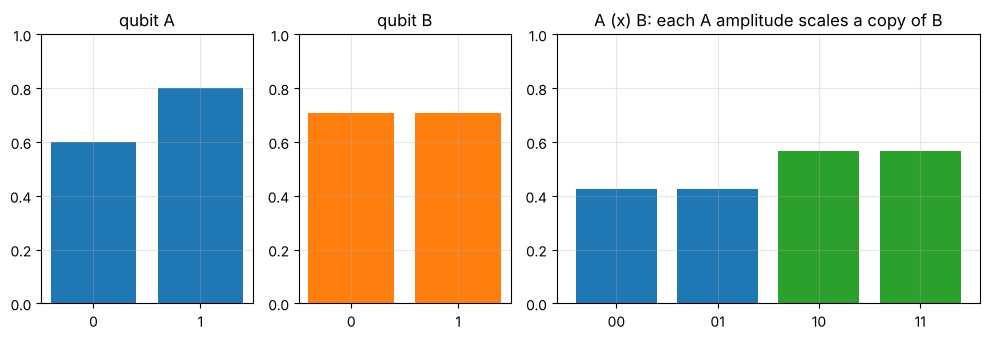

sum of squares still 1: 1.0


In [4]:
a = np.array([0.6, 0.8]); b = np.array([1 / np.sqrt(2), 1 / np.sqrt(2)])
out = np.kron(a, b)
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5), gridspec_kw={"width_ratios": [1, 1, 2]})
axes[0].bar(["0", "1"], a, color="C0"); axes[0].set_title("qubit A")
axes[1].bar(["0", "1"], b, color="C1"); axes[1].set_title("qubit B")
axes[2].bar(["00", "01", "10", "11"], out, color=["C0", "C0", "C2", "C2"]); axes[2].set_title("A (x) B: each A amplitude scales a copy of B")
for ax in axes: ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()
print("sum of squares still 1:", np.sum(np.abs(out) ** 2))

## 2. Exponential growth
n qubits need 2ⁿ complex amplitudes. At 16 bytes each, 30 qubits already need 16 GiB and 50 qubits need about 18 PB.
That gap is where quantum advantage is supposed to come from (Module 9 will be honest about the limits).

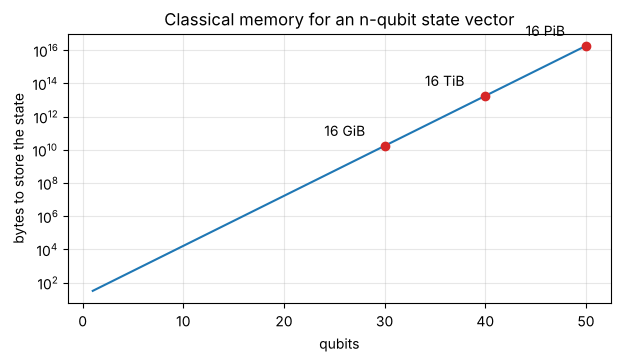

In [5]:
n = np.arange(1, 51)
mem_bytes = (2.0 ** n) * 16
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(n, mem_bytes); ax.set_xlabel("qubits"); ax.set_ylabel("bytes to store the state")
for q, lab in [(30, "16 GiB"), (40, "16 TiB"), (50, "16 PiB")]:
    ax.scatter(q, (2.0 ** q) * 16, color="C3", zorder=3); ax.text(q - 6, (2.0 ** q) * 16 * 4, lab)
ax.set_title("Classical memory for an n-qubit state vector"); plt.show()

## 3. Two-qubit gates are 4×4 matrices
Applying H to qubit A only is **H ⊗ I**. Kronecker products work on matrices too.

In [6]:
H = np.array([[1, 1], [1, -1]]) / np.sqrt(2); I = np.eye(2)
HI = np.kron(H, I)
print("H (x) I =\n", HI)
print("(H (x) I)|00> =", HI @ np.kron(ket0, ket0).real)

H (x) I =
 [[ 0.7071  0.      0.7071  0.    ]
 [ 0.      0.7071  0.      0.7071]
 [ 0.7071  0.     -0.7071 -0.    ]
 [ 0.      0.7071 -0.     -0.7071]]
(H (x) I)|00> = [0.7071 0.     0.7071 0.    ]


## Worked example, every step shown: (a|0⟩ + b|1⟩) ⊗ (c|0⟩ + d|1⟩) with real numbers
Take the first qubit as (0.6, 0.8) and the second as (1/√2, 1/√2) ≈ (0.707, 0.707).

**Recipe:** each entry of the first vector multiplies the **whole** second vector, and the results are stacked:
1. 0.6 × (0.707, 0.707) = (0.424, 0.424) → amplitudes of \|00⟩ and \|01⟩
2. 0.8 × (0.707, 0.707) = (0.566, 0.566) → amplitudes of \|10⟩ and \|11⟩
3. Result: **(0.424, 0.424, 0.566, 0.566)**
4. Check the probabilities add to 1: 0.18 + 0.18 + 0.32 + 0.32 = 1.0 ✓

In [7]:
out = np.kron(np.array([0.6, 0.8]), np.array([1, 1]) / np.sqrt(2))
print("result =", np.round(out, 3), "  sum of squares =", np.sum(out**2))

result = [0.424 0.424 0.566 0.566]   sum of squares = 1.0


## Exercises
**E1.** Compute |0⟩ ⊗ |1⟩ with `np.kron` and say which basis state it is.

**E2.** How many amplitudes does a 10-qubit state have?

In [8]:
# Your turn

<details>
<summary><b>Show worked solution</b></summary>

**E1.** (1, 0) ⊗ (0, 1) = (1·0, 1·1, 0·0, 0·1) = (0, 1, 0, 0), the second basis vector, **|01⟩**.

**E2.** 2¹⁰ = **1,024**.

</details>

In [9]:
assert np.allclose(np.kron(ket0, ket1), [0, 1, 0, 0]) and 2 ** 10 == 1024
print("All Day 9 checks passed.")

All Day 9 checks passed.


---
### Recap checklist
Tick these off in your head before moving on. If any feel shaky, re-run the relevant section with your own numbers.

**Next:** Day 10 (intro): Entanglement and your first Qiskit circuit

*Part of the IIT Delhi CEP Applied Quantum Computing & AI prep plan: [prep-plan.md](../plan/prep-plan.md)*